In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import quad, cumulative_trapezoid

In [90]:
energies = np.logspace(0, 4, 100)[42:]
angles_deg = np.linspace(0, 90, 10)[:-1]
layers = np.arange(1, 11)
radius = 1

In [91]:
grid_x, grid_y, grid_z = np.meshgrid(energies, angles_deg, layers)

In [92]:
survival = np.zeros_like(grid_x)
std_dev = np.zeros_like(grid_x)
avg_dev = np.zeros_like(grid_x)
mesh_i = 0

for i in range(len(energies)):
    for j in range(len(angles_deg)):
        filepath = f"build/output/muon_track_{mesh_i}.txt"
        df = pd.read_csv(filepath, sep=r'\s+', header=0, usecols=[1, 2, 4], 
                        names=['x', 'y', 'rec_e'], dtype={'x': float, 'y': float, 'rec_e': float})
        x_positions = df['x'].values.reshape(-1, 10)
        y_positions = df['y'].values.reshape(-1, 10)
        rec_energies = df['rec_e'].values.reshape(-1, 10)
        dev = np.sqrt(x_positions**2 + y_positions**2)

        dev = np.where(dev > radius*1000, 0, dev)

        sums = dev.sum(axis=0)

        counts = (dev != 0).sum(axis=0)

        survival[j][i] = counts / 1000

        avg  = np.divide(sums, counts, out=np.zeros_like(sums, dtype=float), where=counts!=0)

        avg_dev[j][i] = avg

        std_dev[j][i] = np.sqrt(np.divide(((dev - avg)**2).sum(axis=0), counts, out=np.zeros_like(sums, dtype=float), where=counts!=0))

        mesh_i += 1

In [93]:
size_m2 = radius * radius * np.pi
int_time = 600

In [94]:
e, flux = np.loadtxt("H3a.txt", usecols=(0, 1), unpack=True)
flux_interp = interp1d(e, flux, kind='linear', fill_value="extrapolate")
integral_flux, _ = quad(flux_interp, 1, 10000)

/tmp/ipykernel_211700/2209594210.py:3: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_flux, _ = quad(flux_interp, 1, 10000)


In [95]:
flux_in_scenario = integral_flux * size_m2 * int_time * np.pi * 4

In [96]:
e_grid = np.logspace(0, 4, 100)

pdf = flux_interp(e_grid)
pdf = np.maximum(pdf, 0)

cdf = cumulative_trapezoid(pdf, e_grid, initial=0)

cdf_normalized = cdf / cdf[-1]

inv_cdf = interp1d(cdf_normalized, e_grid, bounds_error=False, fill_value=(e_grid[0], e_grid[-1]))

random_u = np.random.uniform(0, 1, int(flux_in_scenario))

sampled_energies = inv_cdf(random_u)

In [97]:
phi_grid = np.linspace(0, np.pi/2, 10000)

cdf_angles = (2 * phi_grid + np.sin(2 * phi_grid)) / np.pi

inv_cdf = interp1d(cdf_angles, phi_grid, kind='linear')

random_u = np.random.uniform(0, 1, int(flux_in_scenario))

sampled_angles = np.degrees(inv_cdf(random_u))


In [100]:

ei = np.digitize(sampled_energies, energies)
ai = np.digitize(sampled_angles, angles_deg) -1

ei = np.clip(ei, 0, survival.shape[1] - 1)
ai = np.clip(ai, 0, survival.shape[0] - 1)

In [ ]:
dev_values = np.zeros((len(sampled_energies), 10))
for i in range(int(flux_in_scenario)):
    for l in range(10):
        survived = np.random.rand() < survival[ai, ei, l]
        if survived:
            dev_value = np.random.normal(avg_dev[ai, ei, l], std_dev[ai, ei, l])
            dev_values[i, l] = dev_value
        else:
            break

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

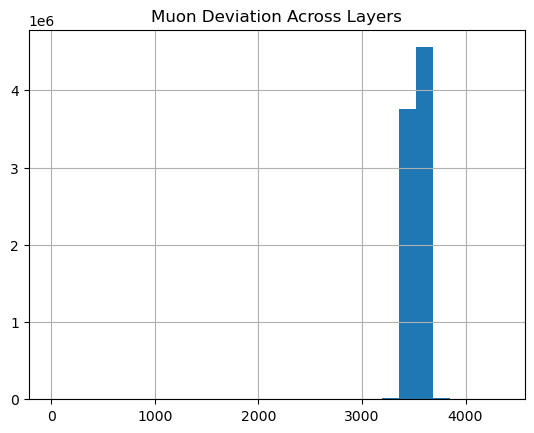

In [ ]:
for devv in dev_values.T:
    plt.hist(devv[devv>0])
plt.title('Muon Deviation Across Layers')
plt.grid()
plt.show()